# ARC3 Game Explorer
**Workflow:** Cell 1 → Cell 2 → Cell 9 (scene analysis) → Cell 7 (execute).

- Cell 4: reset; set `RESET_TO_LEVEL=N` to replay back to any solved level.
- Cell 7: saves completed level solutions automatically.
- Cell 8: action table from game start.
- Cell 9: level analysis + proposed ACTIONS sequence.

In [38]:
# ── Cell 1: Imports and setup ────────────────────────────────────────────────
import sys, os

_here = os.getcwd()
_root = _here
for _ in range(4):
    if os.path.isdir(os.path.join(_root, 'environment_files')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)

NOTEBOOK_VERSION = '2026-06-11 10:30'   # ← updated when notebook is changed
print(f'Notebook version: {NOTEBOOK_VERSION}')
print(f'Working directory: {os.getcwd()}')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from arc_agi import Arcade, OperationMode
from arcengine import GameAction

ARC3_PALETTE = [
    '#FFFFFF','#CCCCCC','#999999','#666666','#333333','#000000',
    '#E53AA3','#FF7BCC','#F93C31','#1E93FF','#88D8F1','#FFDC00',
    '#FF851B','#921231','#4FCC30','#A356D6',
]
ARC3_NAMES = [
    'white','lt-grey','md-grey','dk-grey','vdk-grey','black',
    'pink','lt-pink','red','blue','lt-blue','yellow',
    'orange','maroon','green','purple'
]
cmap = ListedColormap(ARC3_PALETTE)

ACTION_NAMES = {
    'reset': GameAction.RESET,
    '1': GameAction.ACTION1, '2': GameAction.ACTION2,
    '3': GameAction.ACTION3, '4': GameAction.ACTION4,
    '5': GameAction.ACTION5, '6': GameAction.ACTION6,
    '7': GameAction.ACTION7,
}

def show_grid(grid, title='', ax=None, figsize=(10, 10)):
    arr = np.array(grid)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=15, interpolation='nearest', aspect='equal')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(-0.5, arr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, arr.shape[0], 1), minor=True)
    ax.grid(which='minor', color='#888888', linewidth=0.3)
    ax.tick_params(which='minor', size=0)
    vals = sorted(set(arr.flatten()))
    legend_txt = '  '.join(f'{v}={ARC3_NAMES[v]}' for v in vals)
    ax.set_xlabel(f'Values: {legend_txt}', fontsize=8)
    if standalone:
        plt.tight_layout()
        plt.show()

def show_diff(grid_before, grid_after, title_before='Before', title_after='After'):
    """Show before / after / changed-cells stacked vertically — large panels."""
    a = np.array(grid_before)
    b = np.array(grid_after)
    diff = (a != b)
    n_changed = int(diff.sum())
    fig, axes = plt.subplots(3, 1, figsize=(10, 30))
    show_grid(a, title=title_before, ax=axes[0])
    show_grid(b, title=title_after, ax=axes[1])
    diff_img = np.zeros_like(a)
    diff_img[diff] = 8
    axes[2].imshow(diff_img, cmap=cmap, vmin=0, vmax=15,
                   interpolation='nearest', aspect='equal')
    axes[2].set_title(f'Changed cells: {n_changed}', fontsize=12)
    axes[2].set_xticks(np.arange(-0.5, a.shape[1], 1), minor=True)
    axes[2].set_yticks(np.arange(-0.5, a.shape[0], 1), minor=True)
    axes[2].grid(which='minor', color='#888888', linewidth=0.3)
    axes[2].tick_params(which='minor', size=0)
    plt.tight_layout()
    plt.show()
    return n_changed

def print_frame_info(frame, action_taken=''):
    if action_taken:
        print(f'Action taken:      {action_taken}')
    print(f'State:             {frame.state.name}')
    print(f'Levels completed:  {frame.levels_completed} / {frame.win_levels}')
    print(f'Full reset:        {frame.full_reset}')
    print(f'Available actions: {frame.available_actions}')

# ── globals ───────────────────────────────────────────────────────────────────
_env         = None
_last_grid   = None
_game_id     = None
_last_levels = 0
_action_log  = []          # every action taken since last Cell 4 reset
LEVEL_SOLUTIONS = {}       # {N: [full action list from game start to complete level N]}
_arcade = Arcade(operation_mode=OperationMode.OFFLINE)

print('Setup complete.')
games = sorted(set(e.game_id.split('-')[0] for e in _arcade.available_environments))
print('Available games:', ', '.join(games))

Notebook version: 2026-06-11 10:30
Working directory: /Users/rodhyde/Documents/GitHub/arc-agi3-solver
INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
Setup complete.
Available games: ar25, bp35, cd82, cn04, dc22, ft09, g50t, ka59, lf52, lp85, ls20, m0r0, r11l, re86, s5i5, sb26, sc25, sk48, sp80, su15, tn36, tr87, tu93, vc33, wa30


2026-06-12 16:19:05 | INFO | Created new scorecard: aba55904-79a6-4d1f-b0e9-d0d01e10cf9b
2026-06-12 16:19:05 | INFO | Found latest version of ft09: ft09-0d8bbf25 (downloaded: 2026-04-08 20:07:48.508616+00:00)
Loaded: ft09
Win condition: complete 6 levels
Baseline per level: [43, 12, 23, 28, 65, 37]

Action taken:      (initial state)
State:             NOT_FINISHED
Levels completed:  0 / 6
Full reset:        True
Available actions: [6]


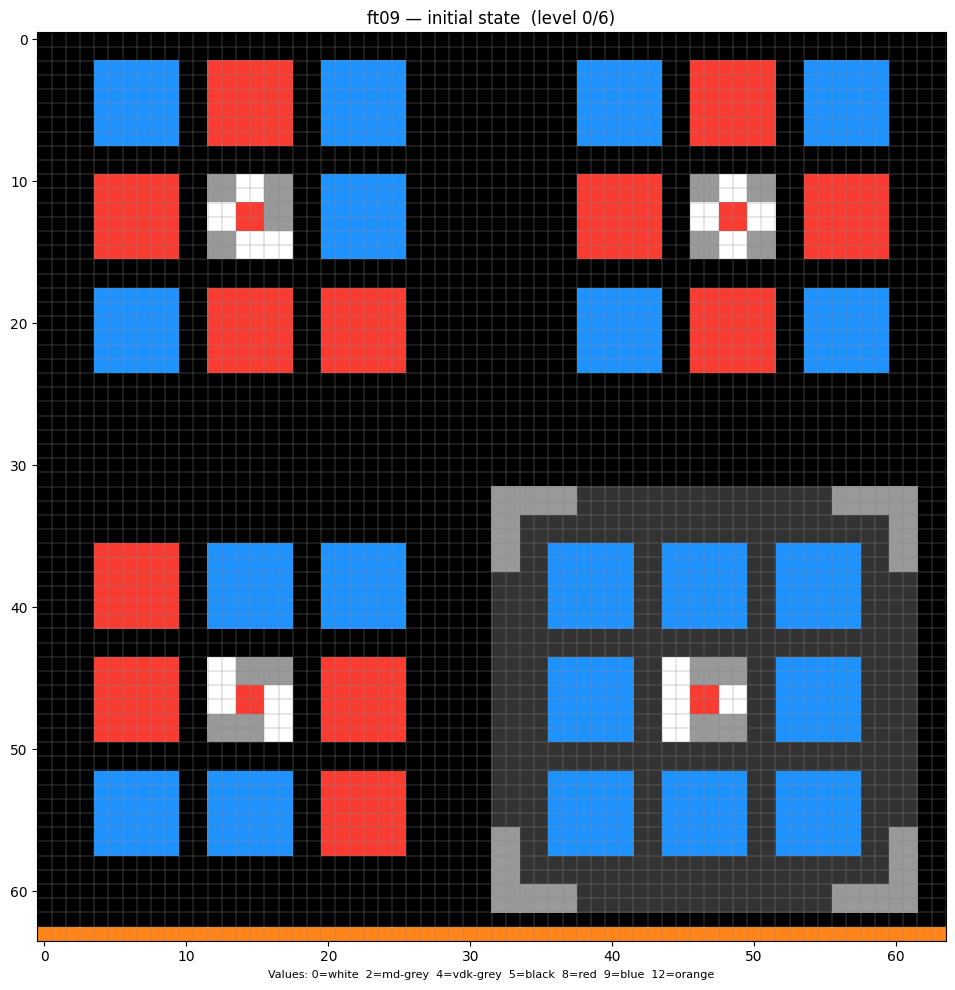

In [39]:
# ── Cell 2: Load a game ───────────────────────────────────────────────────────
GAME = 'ar25'
GAME = 'ft09'
#GAME = 'sb26'

_game_id     = GAME
_env         = _arcade.make(GAME)
_last_levels = 0
_action_log  = []
obs = _env.observation_space
_last_grid = [row.tolist() for row in obs.frame[-1]]

print(f'Loaded: {GAME}')
print(f'Win condition: complete {obs.win_levels} levels')
print(f'Baseline per level: {_env.info.baseline_actions}')
print()
print_frame_info(obs, action_taken='(initial state)')
show_grid(_last_grid, title=f'{GAME} — initial state  (level 0/{obs.win_levels})')


Action taken:      ACTION1
State:             NOT_FINISHED
Levels completed:  0 / 6
Full reset:        False
Available actions: [6]



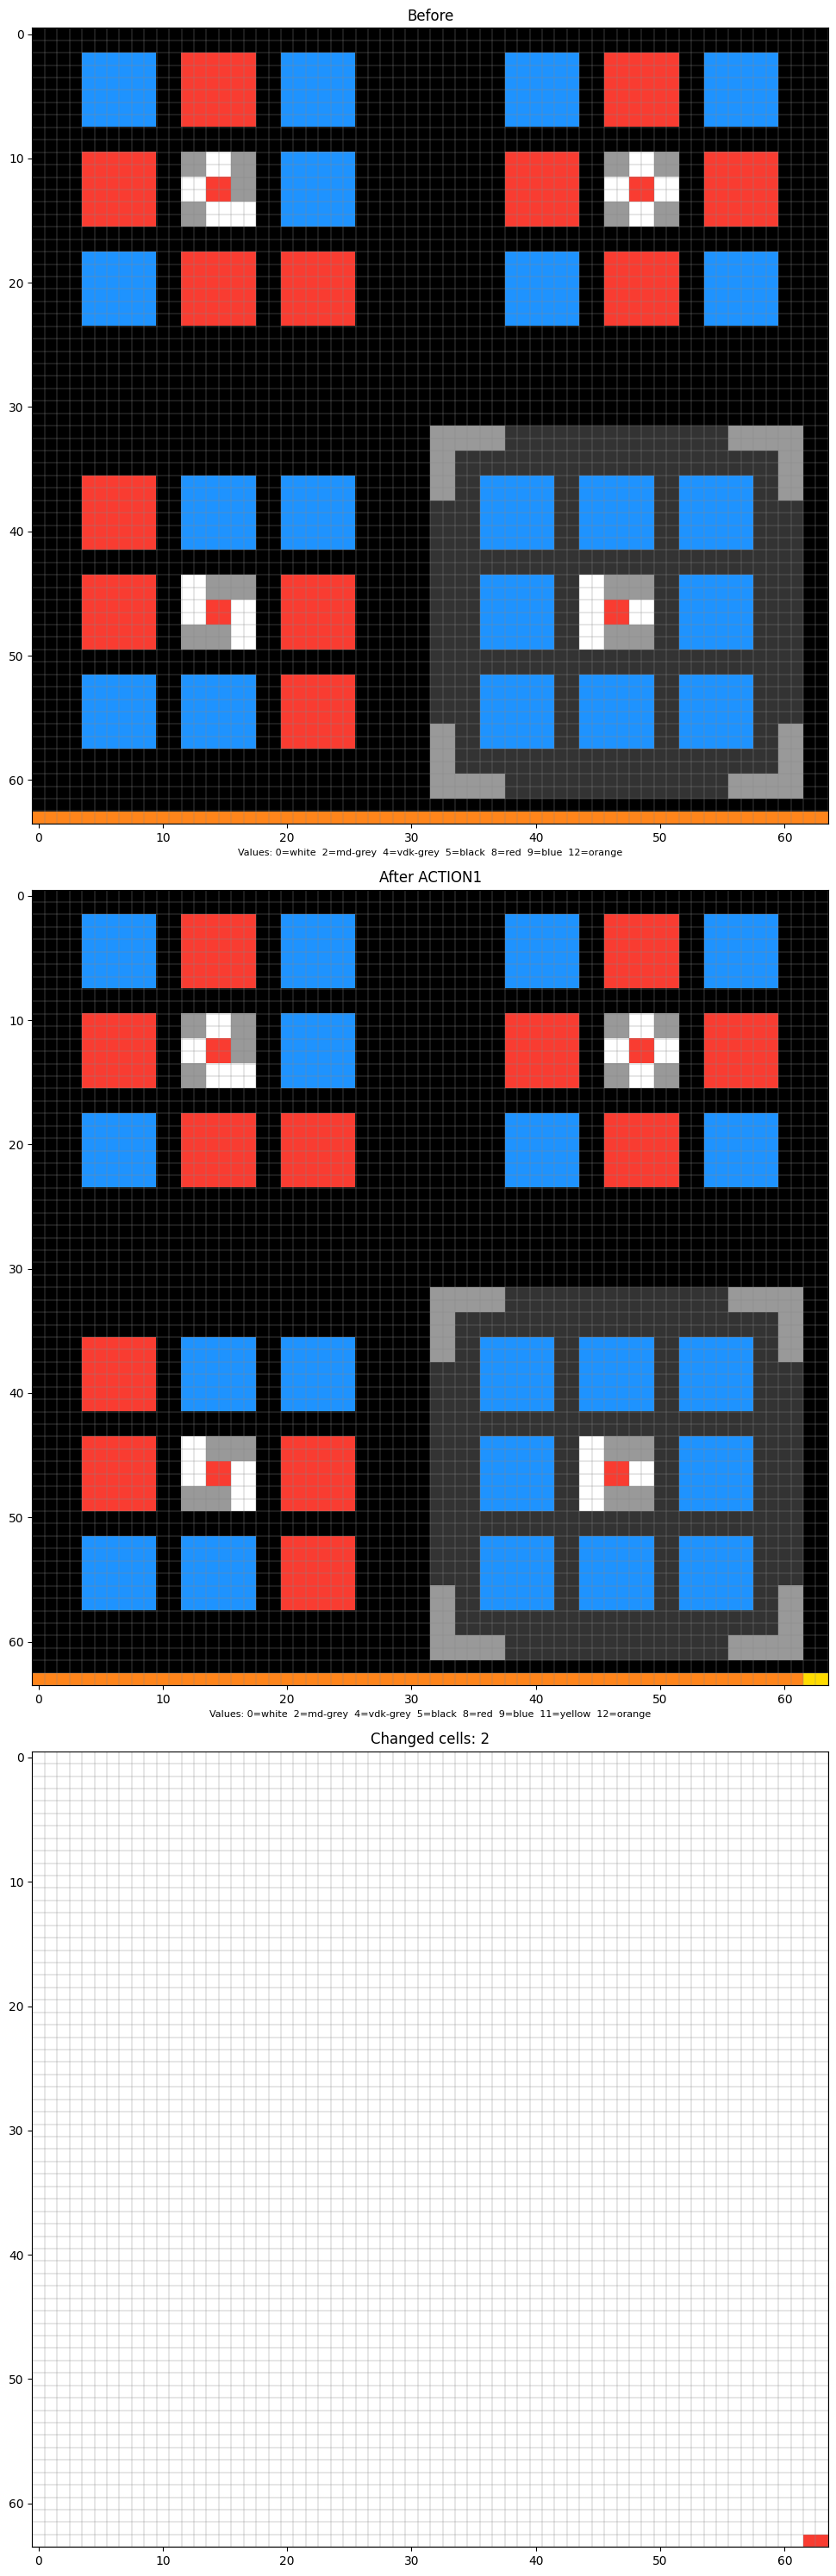

In [40]:
# ── Cell 3: Take one action ───────────────────────────────────────────────────
ACTION = '1'

if _env is None:
    print('Run Cell 2 first.')
else:
    grid_before = _last_grid
    frame = _env.step(ACTION_NAMES[ACTION], data={})
    grid_after = [row.tolist() for row in frame.frame[-1]]
    _last_grid   = grid_after
    _last_levels = frame.levels_completed
    _action_log.append(ACTION)
    print_frame_info(frame, action_taken=f'ACTION{ACTION}')
    print()
    show_diff(grid_before, grid_after,
              title_before='Before',
              title_after=f'After ACTION{ACTION}')


2026-06-12 16:19:28 | INFO | Found latest version of ft09: ft09-0d8bbf25 (downloaded: 2026-04-08 20:07:48.508616+00:00)
Reset ft09 to start. Saved solutions: []
State:             NOT_FINISHED
Levels completed:  0 / 6
Full reset:        True
Available actions: [6]


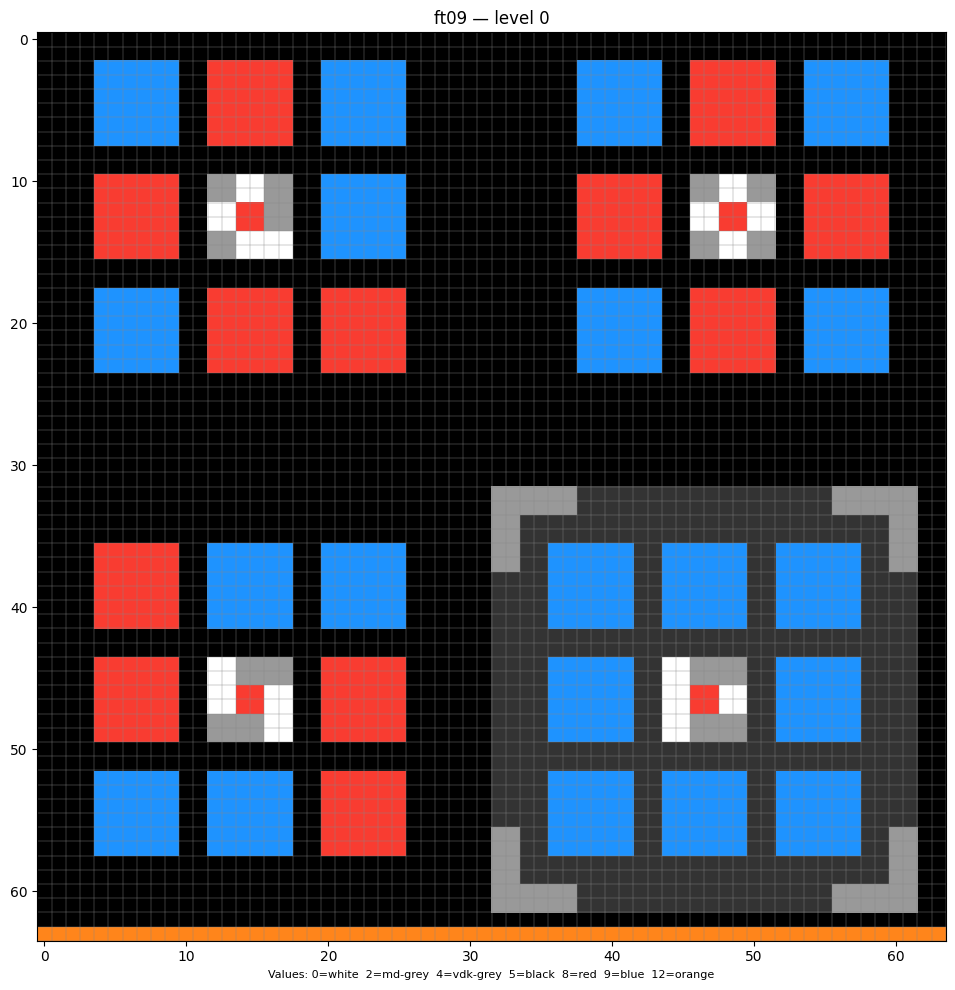

In [41]:
# ── Cell 4: Reset (with optional replay) ─────────────────────────────────────
# RESET_TO_LEVEL = 0  → full reset to game start
# RESET_TO_LEVEL = N  → silently replay saved solutions to reach level N
RESET_TO_LEVEL = 0

if _game_id is None:
    print('Run Cell 2 first.')
else:
    _env = _arcade.make(_game_id)
    obs  = _env.observation_space
    _last_grid   = [row.tolist() for row in obs.frame[-1]]
    _last_levels = 0
    _action_log  = []

    if RESET_TO_LEVEL > 0 and RESET_TO_LEVEL in LEVEL_SOLUTIONS:
        print(f'Replaying to level {RESET_TO_LEVEL}...')
        for act_str in LEVEL_SOLUTIONS[RESET_TO_LEVEL]:
            frame = _env.step(ACTION_NAMES[act_str], data={})
        _last_grid   = [row.tolist() for row in frame.frame[-1]]
        _last_levels = frame.levels_completed
        _action_log  = list(LEVEL_SOLUTIONS[RESET_TO_LEVEL])
        print(f'At level {_last_levels}/{obs.win_levels}.')
        print(f'Saved solutions for levels: {sorted(LEVEL_SOLUTIONS.keys())}')
    else:
        print(f'Reset {_game_id} to start. Saved solutions: {sorted(LEVEL_SOLUTIONS.keys())}')
        print_frame_info(obs)

    show_grid(_last_grid, title=f'{_game_id} — level {_last_levels}')


In [42]:
# ── Cell 5: Survey all games ──────────────────────────────────────────────────
print(f'{"Game":<8}  {"Win levels":<12}  {"Baseline actions":<18}  Available action IDs')
print('-' * 65)
for env_info in sorted(_arcade.available_environments, key=lambda e: e.game_id):
    gid = env_info.game_id.split('-')[0]
    env = _arcade.make(gid)
    if env is None:
        continue
    obs = env.observation_space
    baseline = env_info.baseline_actions or []
    print(f'{gid:<8}  {obs.win_levels:<12}  {len(baseline):<18}  {obs.available_actions}')


Game      Win levels    Baseline actions    Available action IDs
-----------------------------------------------------------------
2026-06-12 16:19:48 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ar25      8             8                   [1, 2, 3, 4, 5, 6, 7]
2026-06-12 16:19:48 | INFO | Found latest version of bp35: bp35-0a0ad940 (downloaded: 2026-04-08 20:07:48.891045+00:00)
bp35      9             9                   [3, 4, 6, 7]
2026-06-12 16:19:48 | INFO | Found latest version of cd82: cd82-fb555c5d (downloaded: 2026-04-08 20:07:49.045128+00:00)
cd82      6             6                   [1, 2, 3, 4, 5, 6]
2026-06-12 16:19:48 | INFO | Found latest version of cn04: cn04-2fe56bfb (downloaded: 2026-04-08 20:07:49.199835+00:00)
cn04      6             6                   [1, 2, 3, 4, 5, 6]
2026-06-12 16:19:48 | INFO | Found latest version of dc22: dc22-fdcac232 (downloaded: 2026-04-08 20:07:48.341428+00:00)
dc22      6         

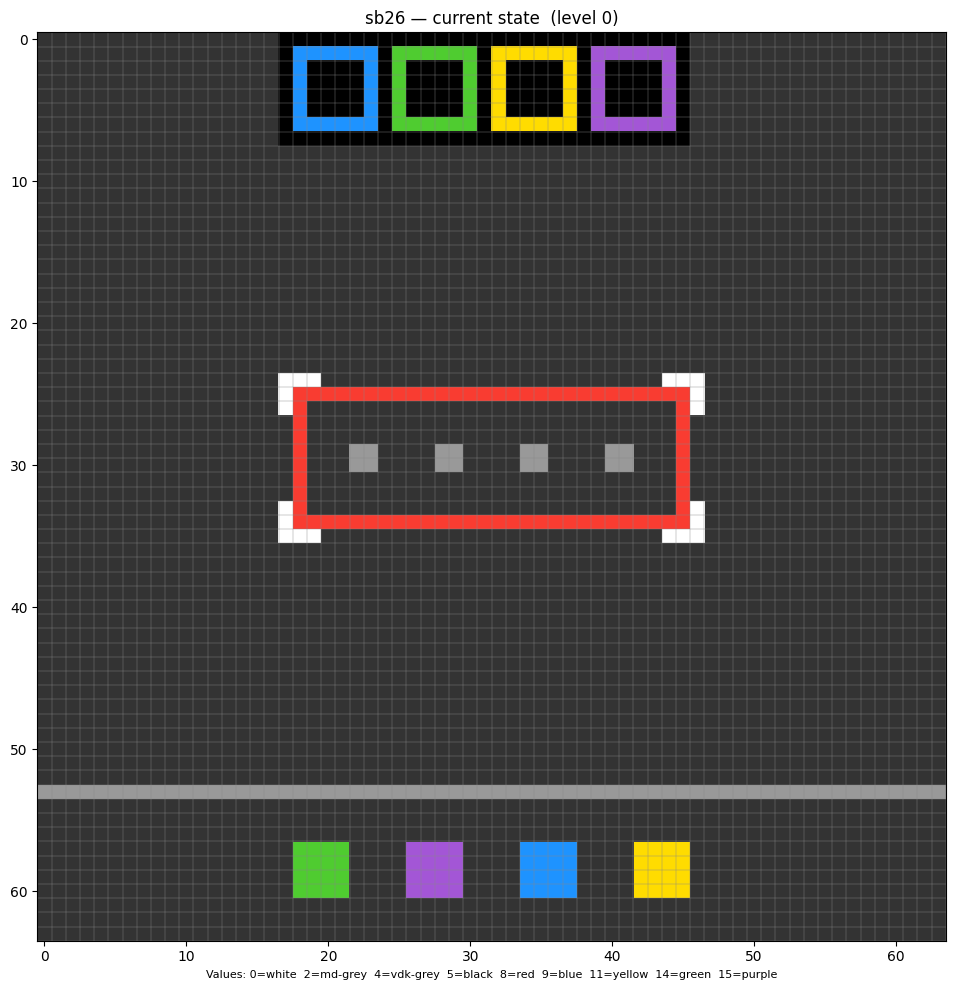

In [18]:
# ── Cell 6: Show current grid ─────────────────────────────────────────────────
if _last_grid is None:
    print('Run Cell 2 first.')
else:
    show_grid(_last_grid, title=f'{_game_id} — current state  (level {_last_levels})')


In [43]:
# ── Cell 7: Step through a sequence — continues from current game state ───────
# Re-run with new ACTIONS to continue from where you left off.
# Run Cell 4 (RESET_TO_LEVEL=N) to jump back to any solved level.
# Completed levels are saved automatically to LEVEL_SOLUTIONS.
#
# Known solutions:
#   Level 1 (15 actions): ['2']*10 + ['3']*5
#   Level 2 (11 actions): ['3','3','5']+['2']*8
#     (horizontal first fast, toggle A5, drop vertically onto target)

ACTIONS = ['2','2','2','2','2','2','2','2','2','2','3','3','3','3','3']  # level 1

ACTIONS = ['3','3','5','2','2','2','2','2','2','2','2']

ACTIONS = ['1','2','3','4','5','6','7']
#ACTIONS = ['1','2','3','4','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5','5']
if _env is None or _game_id is None:
    print('Run Cell 2 first.')
else:
    prev_grid   = _last_grid
    prev_levels = _last_levels

    print(f'Continuing {_game_id} from level {prev_levels}. Win at {_env.observation_space.win_levels}.')
    print(f'Baseline: {_env.info.baseline_actions}\n')

    for i, act_str in enumerate(ACTIONS):
        
        frame = _env.step(ACTION_NAMES[act_str], data={})
        print ('complete? ',i,frame.levels_completed > prev_levels)
        print ('frame',frame,frame.frame[-1])
        curr_grid = [row.tolist() for row in frame.frame[-1]]
        _action_log.append(act_str)

        completed = frame.levels_completed > prev_levels
        finished  = frame.state.name == 'FINISHED'

        if completed:
            LEVEL_SOLUTIONS[frame.levels_completed] = list(_action_log)
            print(f'Step {i+1:2d}: ACTION{act_str}  →  ★ LEVEL {frame.levels_completed} COMPLETE ★  (solution saved)')
            show_grid(prev_grid,
                      title=f'★  Level {prev_levels} — COMPLETED  ★',
                      figsize=(10, 10))
            if not finished:
                show_grid(curr_grid,
                          title=f'Level {frame.levels_completed} — initial state',
                          figsize=(10, 10))
        else:
            tag = f'level {frame.levels_completed}/{frame.win_levels}'
            print(f'Step {i+1:2d}: ACTION{act_str}  →  {tag}')
            # show_diff(prev_grid, curr_grid,
            #           title_before=f'Step {i+1} before ACTION{act_str}',
            #           title_after=f'Step {i+1} after ACTION{act_str}  [{tag}]')

        prev_grid   = curr_grid
        prev_levels = frame.levels_completed

        if finished:
            print('\n★★★  GAME WON!  ★★★')
            break

    _last_grid   = prev_grid
    _last_levels = prev_levels
    print(f'\nFinal: {prev_levels}/{frame.win_levels} levels.  Log: {len(_action_log)} actions total.')
    print(f'Saved solutions: {sorted(LEVEL_SOLUTIONS.keys())}')

Continuing ft09 from level 0. Win at 6.
Baseline: [43, 12, 23, 28, 65, 37]

complete?  0 False
frame {
  "game_id": "ft09-0d8bbf25",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 6,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "737e531c-7541-4272-b0be-86732fecca79",
  "full_reset": false,
  "available_actions": [
    6
  ]
} [[ 5  5  5 ...  5  5  5]
 [ 5  5  5 ...  5  5  5]
 [ 5  5  5 ...  5  5  5]
 ...
 [ 5  5  5 ...  2  5  5]
 [ 5  5  5 ...  5  5  5]
 [12 12 12 ... 12 11 11]]
Step  1: ACTION1  →  level 0/6
complete?  1 False
frame {
  "game_id": "ft09-0d8bbf25",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 6,
  "action_input": {
    "id": 2,
    "data": {},
    "reasoning": null
  },
  "guid": "737e531c-7541-4272-b0be-86732fecca79",
  "full_reset": false,
  "available_actions": [
    6
  ]
} [[ 5  5  5 ...  5  5  5]
 [ 5  5  5 ...  5  5  5]
 [ 5  5  5 ...  5  5  5]
 ...
 [ 5  5  5 ...  2  5  5]
 [ 5

2026-06-12 08:13:48 | INFO | Found latest version of ft09: ft09-0d8bbf25 (downloaded: 2026-04-08 20:07:48.508616+00:00)
Action table for ft09 (from game start)
Available actions: [6]
Baseline per level: [43, 12, 23, 28, 65, 37]



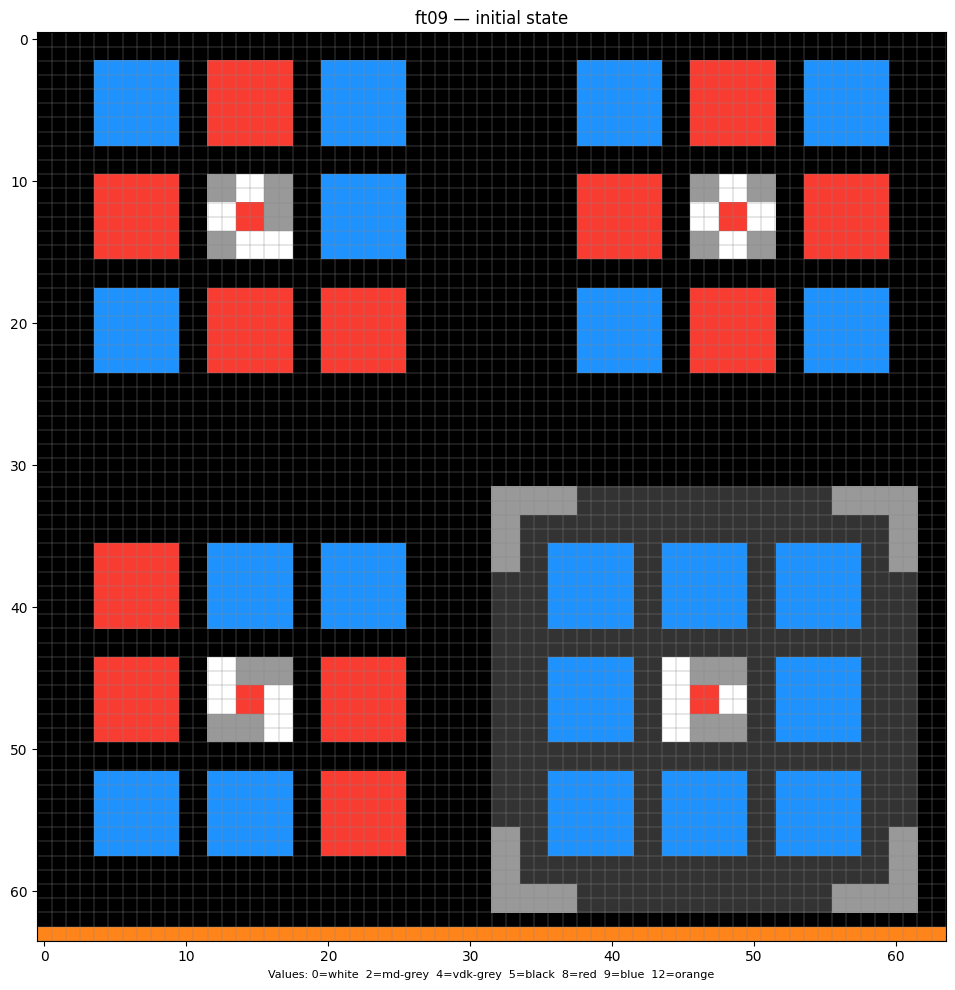

2026-06-12 08:13:48 | INFO | Found latest version of ft09: ft09-0d8bbf25 (downloaded: 2026-04-08 20:07:48.508616+00:00)
ACTION6: no change


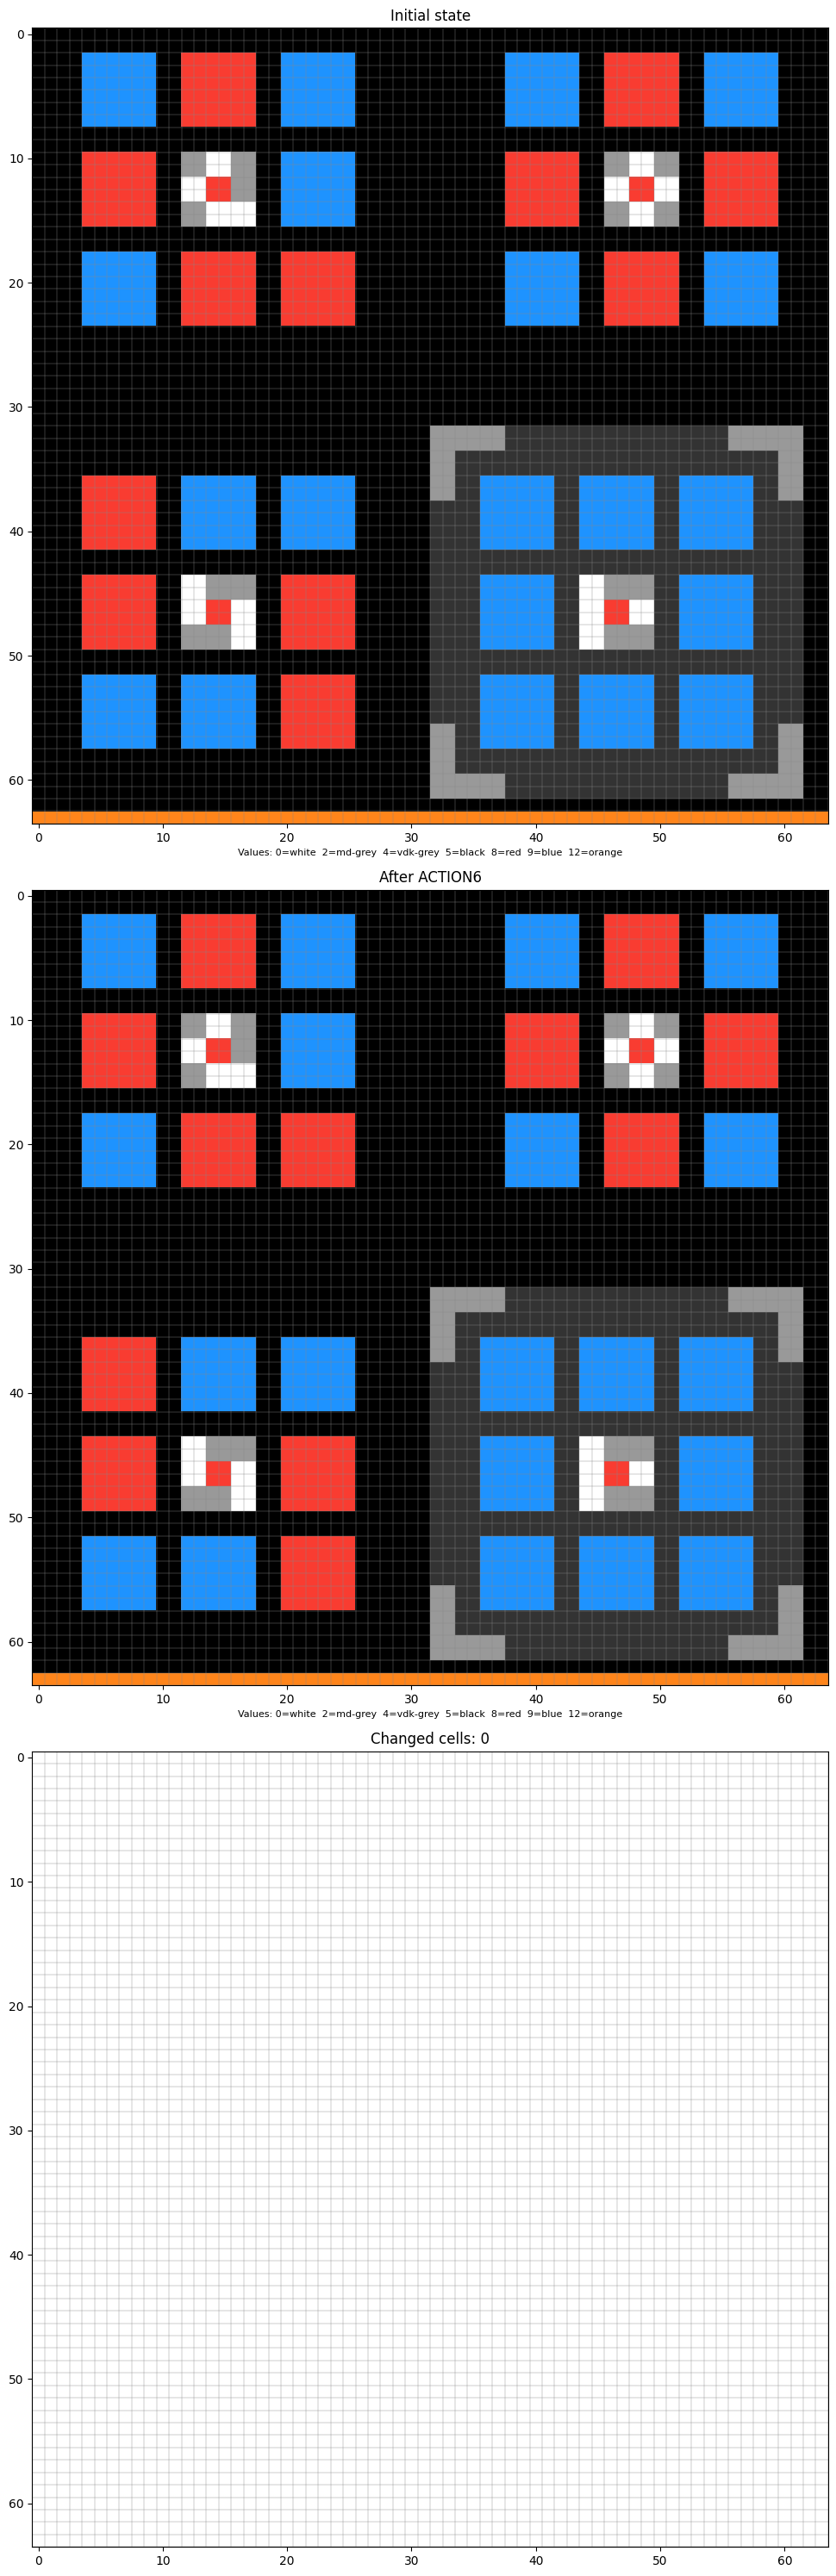


── Summary ──────────────────────────────────────────────────────────
  ACTION6: no change


In [12]:
# ── Cell 8: Action table — object-level description of each action ────────────
# Probes each available action once from a FRESH game state.
# Groups colours that move together as a single compound object.

if _game_id is None:
    print('Run Cell 2 first.')
else:
    import numpy as np
    from collections import defaultdict, deque

    def describe_changes(before_grid, after_grid):
        a = np.array(before_grid)
        b = np.array(after_grid)
        diff = (a != b)
        if not diff.any():
            return ['no change']
        per_colour = {}
        for colour in sorted(set(a[diff].tolist()) | set(b[diff].tolist())):
            lost   = diff & (a == colour)
            gained = diff & (b == colour)
            n_lost, n_gained = int(lost.sum()), int(gained.sum())
            mismatch = abs(n_lost - n_gained)
            near_equal = (n_lost > 0 and n_gained > 0
                          and mismatch <= max(2, int(0.1 * max(n_lost, n_gained))))
            if near_equal:
                lr, lc = np.where(lost);  gr, gc = np.where(gained)
                dr = float(np.mean(gr) - np.mean(lr))
                dc = float(np.mean(gc) - np.mean(lc))
                direction = ('down' if dr > 0 else 'up') if abs(dr) >= abs(dc) else ('right' if dc > 0 else 'left')
                dist = abs(dr) if abs(dr) >= abs(dc) else abs(dc)
                note = f'~{max(n_lost,n_gained)}' if mismatch else str(n_lost)
                per_colour[colour] = ('move', direction, round(dist,1), note)
            elif n_lost > 0 and n_gained == 0:
                lr, lc = np.where(lost)
                per_colour[colour] = ('gone', float(np.mean(lr)), float(np.mean(lc)), n_lost)
            elif n_gained > 0 and n_lost == 0:
                gr, gc = np.where(gained)
                per_colour[colour] = ('appeared', float(np.mean(gr)), float(np.mean(gc)), n_gained)
            else:
                per_colour[colour] = ('changed', n_lost, n_gained)

        move_groups = defaultdict(list)
        other_events = []
        for colour, info in per_colour.items():
            if info[0] == 'move':
                move_groups[(info[1], info[2])].append((colour, info[3]))
            else:
                other_events.append((colour, info))

        descriptions = []
        for (direction, dist), members in sorted(move_groups.items()):
            if len(members) > 1:
                parts  = '+'.join(ARC3_NAMES[c] for c, _ in members)
                counts = '+'.join(str(n) for _, n in members)
                descriptions.append(f'[{parts}] ({counts} cells) moved {direction} ~{dist:.0f}')
            else:
                colour, n = members[0]
                descriptions.append(f'{ARC3_NAMES[colour]} ({n} cells) moved {direction} ~{dist:.0f}')
        for colour, info in other_events:
            name = ARC3_NAMES[colour]
            if info[0] == 'gone':
                descriptions.append(f'{name} ({info[3]} cells) disappeared from ~({info[1]:.0f},{info[2]:.0f})')
            elif info[0] == 'appeared':
                descriptions.append(f'{name} ({info[3]} cells) appeared at ~({info[1]:.0f},{info[2]:.0f})')
            else:
                descriptions.append(f'{name}: {info[1]} cells lost, {info[2]} cells gained')
        return descriptions

    env0 = _arcade.make(_game_id)
    obs0 = env0.observation_space
    initial_grid = [row.tolist() for row in obs0.frame[-1]]
    available    = obs0.available_actions

    print(f'Action table for {_game_id} (from game start)')
    print(f'Available actions: {available}')
    print(f'Baseline per level: {env0.info.baseline_actions}\n')

    show_grid(initial_grid, title=f'{_game_id} — initial state', figsize=(10,10))

    summary = []
    for act_id in available:
        ep = _arcade.make(_game_id)
        frame = ep.step(ACTION_NAMES[str(act_id)], data={})
        probe_grid = [row.tolist() for row in frame.frame[-1]]
        descs = describe_changes(initial_grid, probe_grid)
        summary.append((act_id, descs))
        print(f'ACTION{act_id}: {"  |  ".join(descs)}')
        show_diff(initial_grid, probe_grid,
                  title_before='Initial state',
                  title_after=f'After ACTION{act_id}')

    print('\n── Summary ──────────────────────────────────────────────────────────')
    for act_id, descs in summary:
        for d in descs:
            print(f'  ACTION{act_id}: {d}')
